<a href="https://colab.research.google.com/github/lesterlnds/lesterlnds/blob/main/Landaos_Activity_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY 6.1** | **Performing Face Recognition**
**Name** | Landaos, Lester
**Section** | CPE 018-CPE31S2
**Date Performed**: | 3/3/26
**Date Submitted**: | 3/3/26
**Instructor**: | Engr. Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform data preparation and face recognition on their own generated dataset.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize data preparation techniques for images.
* Perform Face Recognition using multiple algorithms.
* Evaluate the performance of different algorithms.

## 3. Procedures and Outputs

### Preparing the training data

Now that we have our data, we need to load these sample pictures into our face recognition algorithms. All face recognition algorithms take two parameters in their `train()` method: an array of images and an array of labels. What do these labels represent? They are the IDs of a certain individual/face so that when face recognition is performed, we not only know the person was recognized but also who—among the many people available in our database—the person is.

To do that, we need to create a comma-separated value (CSV) file, which will contain the path to a sample picture followed by the ID of that person.

**Include a Screenshot of Your Dataset Here**

---

### Loading the data and recognizing faces

Next up, we need to load these two resources (the array of images and CSV file) into the face recognition algorithm, so it can be trained to recognize our face. To do this, we build a function that reads the CSV file and—for each line of the file—loads the image at the corresponding path into the images array and the ID into the labels array.

In [105]:
import numpy as np
import os
import errno
import sys
import cv2

def read_images(path, sz=None):
  c = 0
  X, y = [], []

  for dirname, dirnames, filenames in os.walk(path):
    for subdirname in dirnames:
      subject_path = os.path.join(dirname, subdirname)
      for filename in os.listdir(subject_path):
        try:
          if(filename == ".directory"):
            continue
          filepath = os.path.join(subject_path, filename)
          im = cv2.imread(os.path.join(subject_path, filename), cv2.IMREAD_GRAYSCALE)

          # Resize the images to the prescribed size
          if (sz is not None):
            im = cv2.resize(im, (200,200))

          X.append(np.asarray(im, dtype=np.uint8))
          y.append(c)

        except IOError as e:
          print(f"I/O Error({e.errno}): {e.strerror}")
        except:
          print("Unexpected error:", sys.exc_info()[0])
          raise
      c = c+1
  return [X, y]

**Question: Run the function above on your generated dataset. Provide an analysis and note all the challenges you have encountered running this code.**

---

### Performing Face Recognition Algorithms

Here is a sample script for testing the Face Recognition Algorithm. In this section, we're going to follow the same process but with different algorithms for face recognitions, namely:
- Eigenface Recognition
- Fisherface Recognition
- Local Binary Pattern Histograms (LBPH) Recognition

In [118]:
import numpy as np
import cv2
import os
from google.colab.patches import cv2_imshow

def face_rec(dataset_path):
    names = ['faces', 'Smile']
    X, y = read_images(dataset_path, sz=(250,250))
    y = np.asarray(y, dtype=np.int32)
    model = cv2.face.EigenFaceRecognizer_create()
    model.train(X, y)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + '/content/haarcascade_frontalface_default.xml'
    )
    test_image_path = "/content/drive/MyDrive/CPE-018/Activity7/faces.jpg"
    img = cv2.imread(test_image_path)
    if img is None:
        print("Test image not found!")
        return
    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_full, 1.3, 5)
    for (x, y_pos, w, h) in faces:
        face = gray_full[y_pos:y_pos+h, x:x+w]
        roi = cv2.resize(face, (250, 250))
        label, confidence = model.predict(roi)
        cv2.rectangle(img, (x, y_pos), (x+w, y_pos+h), (255,0,0), 2)
        cv2.putText(img,
                    names[label] + " " + str(round(confidence,2)),
                    (x, y_pos-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255,0,0),
                    2)
    cv2_imshow(img)

**Question: Provide an analysis of the sample script for the process using the Eigenface Model. What is the sample code doing? Are you able to troubleshoot any problems encountered?**

---
Perform the remaining face recognition techniques by using the same (or modified) process from the sample code:

- `model = cv2.face.createFisherFaceRecognizer()`
- `model = cv2.face.createLBPHFaceRecognizer()`

**Question: The `predict()` method returns a two-element array. Provide your analysis of the two returned values and their important ince this application.**

## 4. Supplementary Activity

Your accomplisment of the tasks below contribute to the achievement of ILO1, ILO2, and ILO3 for this module.

---

Tasks:
1. Create a new dataset for testing, this dataset must include the following:
  - The same person/s that the model has to recognize.
  - Different person/s that the model should not recognize.
2. For each model, perform 20 tests. Document the testing performed and provide observations.
3. Conclude on the performed tests by providing your evaluation of the performance of the models.

In [107]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/CPE-018/Activity7"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


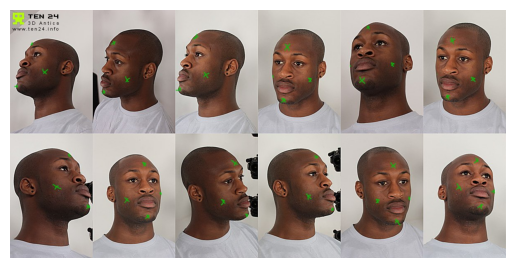

In [108]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/CPE-018/Activity7/faces.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

In [109]:
import os
dataset_path = "/content/drive/MyDrive/CPE-018/Activity7"
print("Inside dataset:", os.listdir(dataset_path))

Inside dataset: ['faces.jpg', 'Smile.png', 'Lakers.jpg', 'sample.jpg', 'ss.jpeg']


In [110]:
import numpy as np
import os
import cv2

def read_images(path, sz=None):
    X, y = [], []
    if not os.path.exists(path):
        print("Dataset path does NOT exist!")
        return X, y
    label = 0
    for folder_name in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder_name)
        if not os.path.isdir(folder_path):
            continue
        print("Reading folder:", folder_name)
        for filename in os.listdir(folder_path):
            if filename.startswith("."):
                continue
            filepath = os.path.join(folder_path, filename)
            im = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
            if im is None:
                print("Could not read:", filepath)
                continue
            if sz is not None:
                im = cv2.resize(im, sz)
            X.append(im)
            y.append(label)
        label += 1
    return X, y

In [111]:
import os
for root, dirs, files in os.walk(dataset_path):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files)
    print("------")

ROOT: /content/drive/MyDrive/CPE-018/Activity7
DIRS: []
FILES: ['faces.jpg', 'Smile.png', 'Lakers.jpg', 'sample.jpg', 'ss.jpeg']
------


In [112]:
import numpy as np
import cv2
import os
from google.colab.patches import cv2_imshow

def face_rec(dataset_path):
    names = ['faces', 'Smile']
    X, y = read_images(dataset_path, sz=(250,250))
    y = np.asarray(y, dtype=np.int32)
    model = cv2.face.EigenFaceRecognizer_create()
    model.train(X, y)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    test_image_path = "/content/drive/MyDrive/CPE-018/Activity7/faces.jpg"
    img = cv2.imread(test_image_path)
    if img is None:
        print("Test image not found!")
        return
    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_full, 1.3, 5)
    for (x, y_pos, w, h) in faces:
        face = gray_full[y_pos:y_pos+h, x:x+w]
        roi = cv2.resize(face, (250, 250))
        label, confidence = model.predict(roi)
        cv2.rectangle(img, (x, y_pos), (x+w, y_pos+h), (255,0,0), 2)
        cv2.putText(img,
                    names[label] + " " + str(round(confidence,2)),
                    (x, y_pos-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255,0,0),
                    2)
    cv2_imshow(img)

In [113]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Image loaded!


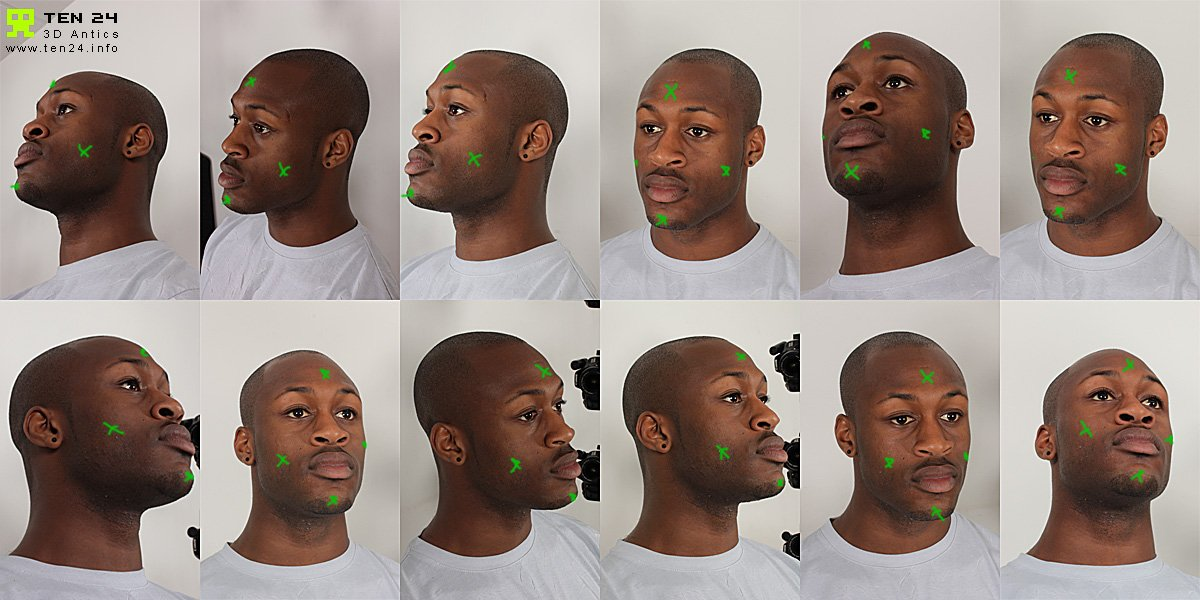

In [114]:
from google.colab.patches import cv2_imshow
import cv2

test_image_path = "/content/drive/MyDrive/CPE-018/Activity7/faces.jpg"
img = cv2.imread(test_image_path)
if img is None:
    print("Image not found!")
else:
    print("Image loaded!")
    cv2_imshow(img)

In [115]:
print("Faces detected:", len(faces))

Faces detected: 1


Faces detected: 1


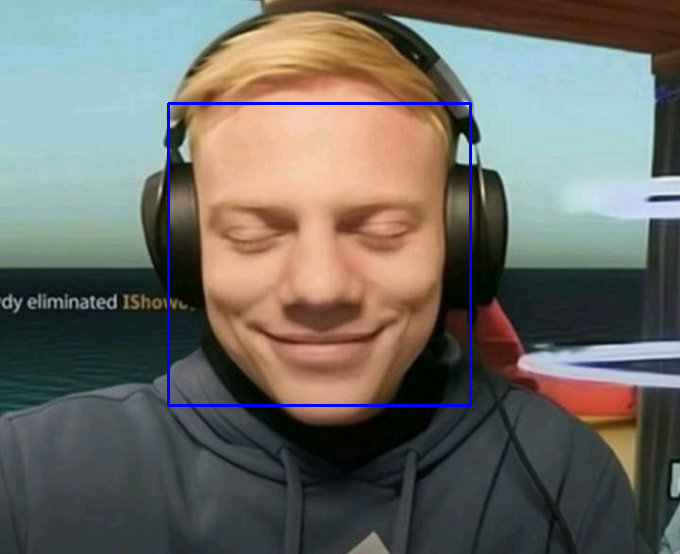

In [116]:
from google.colab.patches import cv2_imshow
import cv2

image_path = "/content/drive/MyDrive/CPE-018/Activity7/Smile.png"
img = cv2.imread(image_path)
if img is None:
    print("Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )
    print("Faces detected:", len(faces))
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2_imshow(img)

## 5. Summary, Conclusions and Lessons Learned

Performing this activity enabled me to effectively use a dataset from the internet, and implement it in Google Colab for data preparation and face recognition. I was able to effectively preprocess images, arrange the dataset, and apply several face recognition algorithms without worrying about local hardware constraints by using Colab's cloud-based environment. My comprehension of how appropriate data preparation greatly influences recognition accuracy has been reinforced by the practical experience. I was able to determine the advantages, disadvantages, and general performance of various algorithms on the same dataset by comparing them. My analytical abilities and comprehension of model metrics were further improved by evaluating the outcomes. All things considered, finishing this Colab assignment gave me both real-world technical experience and a better comprehension of face recognition systems.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*